# Query-weighted digit projection

This notebook gives a small real-data illustration.  The scikit-learn digits are 64-dimensional images.  We standardize them, project to three principal components, normalize to the sphere `S^2`, and then assign query-specific weights by a softmax of cosine similarity in the original standardized image space.

This is a **projected spherical workflow**, not full high-dimensional harmonic fitting.  Its purpose is to show how the same GID tools handle query-dependent weighted probability measures.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:

rng = np.random.default_rng(20260706)

digits = load_digits()
X_raw = digits.data.astype(float)
y = digits.target
X_std = StandardScaler().fit_transform(X_raw)

# Projection used only to obtain points on S^2 for this low-dimensional demonstration.
Z3 = PCA(n_components=3, random_state=0).fit_transform(X_std)
S2 = src.normalize_rows(Z3)

# Quadrature for the fitted level 1/2 models.
quad_X, quad_w = src.fibonacci_sphere(7000)

def query_weights(query_index, tau=6.0):
    q = X_std[query_index]
    q = q / np.linalg.norm(q)
    Xn = X_std / np.maximum(np.linalg.norm(X_std, axis=1, keepdims=True), 1e-12)
    scores = tau * (Xn @ q)
    scores -= scores.max()
    return src.normalize_weights(np.exp(scores))

query_indices = []
for digit in [0, 1, 8]:
    query_indices.append(int(np.where(y == digit)[0][0]))

rows = []
for qi in query_indices:
    digit = int(y[qi])
    w = query_weights(qi, tau=6.0)
    fit = src.fit_s2_level12(S2, w, quad_X, quad_w)
    masses = pd.Series(w).groupby(y).sum().sort_values(ascending=False)
    top_mass = ", ".join([f"{int(k)}:{v:.2f}" for k, v in masses.head(3).items()])
    rows.append({
        "Query digit": digit,
        "ESS": src.effective_sample_size(w),
        "I1": fit["I"][0],
        "I2": fit["I"][1],
        "D2": fit["D"][-1],
        "Top class masses": top_mass,
    })

pd.DataFrame(rows).round({"ESS": 1, "I1": 3, "I2": 3, "D2": 3})


,Query digit,ESS,I1,I2,D2,Top class masses
0,0,162.6,1.695,0.276,1.970,"0:0.85, 9:0.05, 4:0.03"
1,1,138.2,1.166,0.153,1.319,"1:0.72, 8:0.06, 4:0.06"
2,8,85.5,0.248,0.032,0.280,"8:0.46, 3:0.12, 9:0.11"


The table summarizes the query-specific weighted empirical measures.  A query whose neighbors are concentrated in the projected spherical space has larger cumulative information.  A more diffuse query has smaller gaps and often lower effective sample size.

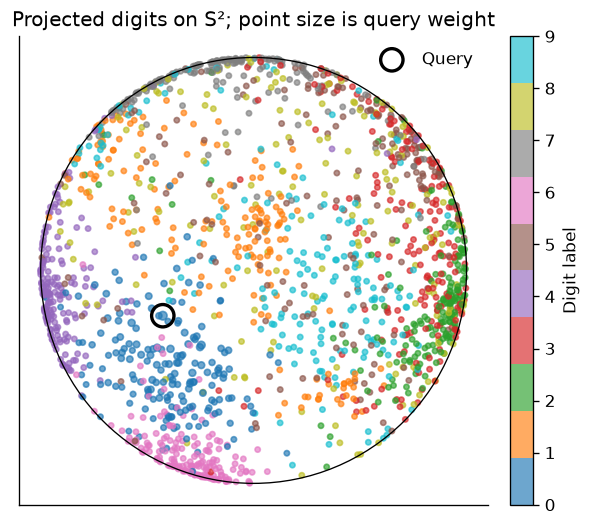

In [3]:

# Visualize one query's weighted measure on the projected sphere.
query_digit = 0
qi = query_indices[0]
w = query_weights(qi, tau=6.0)
xx, yy = src.orthographic_project_s2(S2)

fig, ax = plt.subplots(figsize=(5.2, 4.5))
sc = ax.scatter(xx, yy, c=y, s=10 + 600*w, alpha=0.65, cmap="tab10")
ax.scatter(xx[qi], yy[qi], s=180, facecolor="none", edgecolor="black", linewidth=2.0, label="Query")
ax.add_patch(plt.Circle((0, 0), 1, fill=False, linewidth=0.8))
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Projected digits on S²; point size is query weight")
ax.legend(frameon=False, loc="upper right")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Digit label")
fig.tight_layout()
plt.show()


The point sizes are proportional to the query weights.  This makes the observed object a weighted probability measure on the sphere, even though the original data are images.